In [10]:
#pip install earthengine-api geemap

In [11]:
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from ipyleaflet import WidgetControl

In [12]:
# Activar el proceso de autenticación de Google Earth Engine
ee.Authenticate()
ee.Initialize()

print("¡Conexión exitosa!")

¡Conexión exitosa!


In [13]:
#Zona de Estudio y Entrenamiento (UTP - Betania)
roi_estudio = ee.Geometry.Rectangle([
    -79.551101, 9.000870, -79.499710, 9.040796
])

# Inicializar y centrar el mapa en la zona del estudio
mapa = geemap.Map()
mapa.centerObject(roi_estudio, 13)

# Desplegar capas visuales
mapa.addLayer(roi_estudio, {'color': 'FF0000'}, 'Zona de Estudio (UTP)', opacity=0.3)
mapa

Map(center=[9.020833524166905, -79.52540550000283], controls=(WidgetControl(options=['position', 'transparent_…

In [14]:
# Función de preprocesamiento de Sentinel-2
def procesar_sentinel(imagen):
    qa = imagen.select('QA60')
    bits_nube = (1 << 10) | (1 << 11)
    mascara = qa.bitwiseAnd(bits_nube).eq(0)
    img_limpia = imagen.updateMask(mascara).divide(10000)
    
    ndvi = img_limpia.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return img_limpia.addBands(ndvi).copyProperties(imagen, ["system:time_start"])


print("Extrayendo patrones históricos de la UTP para entrenar el modelo...")

coleccion_historica = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
                       .filterDate('2018-01-01', '2024-04-30')
                       .filterBounds(roi_estudio)
                       .filter(ee.Filter.calendarRange(1, 4, 'month'))
                       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                       .map(procesar_sentinel))

mosaico_entrenamiento = coleccion_historica.median()

# Auto-etiquetado interno
# Clase 0: Urbano (NDVI < 0.3) | Clase 1: Bosque (NDVI > 0.55)
banda_clases = ee.Image().expression(
    "(NDVI < 0.3) ? 0 : ((NDVI > 0.55) ? 1 : 2)",
    {'NDVI': mosaico_entrenamiento.select('NDVI')}
).rename('clase')

# Filtrar píxeles dudosos (Clase 2)
banda_clases = banda_clases.updateMask(banda_clases.neq(2))

# Extraer muestras por clase directamente de la UTP
imagen_para_muestreo = mosaico_entrenamiento.select('NDVI').addBands(banda_clases)

datos_entrenamiento = imagen_para_muestreo.stratifiedSample(
    numPoints=500,
    classBand='clase',
    region=roi_estudio,
    scale=10,
    geometries=True
)

# Entrenar el modelo Random Forest
clasificador_rf = ee.Classifier.smileRandomForest(50).train(
    features=datos_entrenamiento,
    classProperty='clase',
    inputProperties=['NDVI']
)
print("Modelo Random Forest entrenado.")

Extrayendo patrones históricos de la UTP para entrenar el modelo...
Modelo Random Forest entrenado.


In [15]:
print("Calculando la evolución de la cobertura (2018-2026). Esto tomará unos segundos...")

anios_estudio = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
historico_urbano = []
historico_bosque = []

# Función auxiliar para extraer hectáreas
def obtener_hectareas(imagen_clasificada):
    area = ee.Image.pixelArea().addBands(imagen_clasificada).reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName='clase'),
        geometry=roi_estudio,
        scale=10,
        maxPixels=1e9
    ).getInfo()
    ha_u, ha_b = 0, 0
    if area and 'groups' in area:
        for g in area['groups']:
            if g['clase'] == 0: ha_u = g['sum'] / 10000
            elif g['clase'] == 1: ha_b = g['sum'] / 10000
    return ha_u, ha_b

for anio in anios_estudio:
    coleccion_anio = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
                      .filterDate(f'{anio}-01-01', f'{anio}-04-30')
                      .filterBounds(roi_estudio)
                      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
                      .map(procesar_sentinel))
    
    if coleccion_anio.size().getInfo() == 0:
        historico_urbano.append(None)
        historico_bosque.append(None)
        continue
        
    clasificacion = coleccion_anio.median().select(['NDVI']).classify(clasificador_rf).clip(roi_estudio)
    u, b = obtener_hectareas(clasificacion)
    historico_urbano.append(u)
    historico_bosque.append(b)

print("Análisis estadístico base completado.")

Calculando la evolución de la cobertura (2018-2026). Esto tomará unos segundos...
Análisis estadístico base completado.


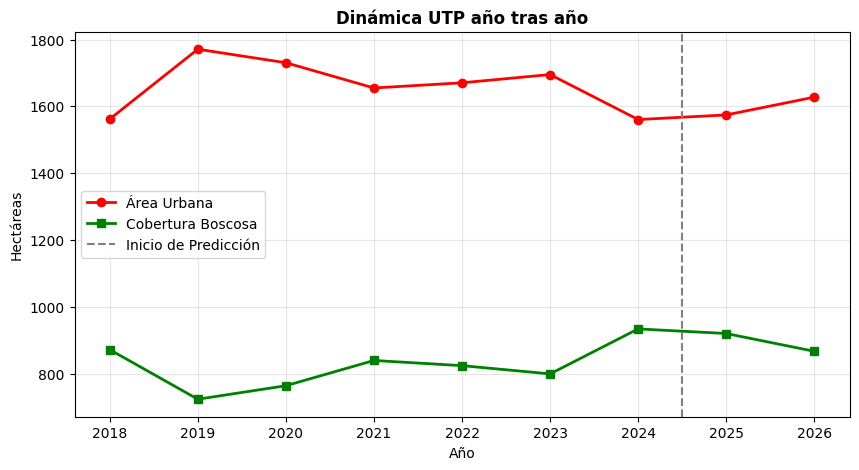

In [16]:
# --- GRÁFICA ---
df = pd.DataFrame({'Año': anios_estudio, 'Urbano': historico_urbano, 'Bosque': historico_bosque})
plt.figure(figsize=(10, 5))
plt.plot(df['Año'], df['Urbano'], color='red', marker='o', linewidth=2, label='Área Urbana')
plt.plot(df['Año'], df['Bosque'], color='green', marker='s', linewidth=2, label='Cobertura Boscosa')
plt.axvline(x=2024.5, color='gray', linestyle='--', label='Inicio de Predicción')
plt.title('Dinámica UTP año tras año', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Hectáreas')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:
def preparar_para_tendencia(imagen):
    año = ee.Image(imagen.date().get('year')).rename('year').toFloat()
    return año.addBands(imagen.select('NDVI'))

coleccion_tendencia = coleccion_historica.map(preparar_para_tendencia)
ajuste_lineal = coleccion_tendencia.reduce(ee.Reducer.linearFit())
pendiente = ajuste_lineal.select('scale')
interseccion = ajuste_lineal.select('offset')

def obtener_hectareas(imagen_clasificada):
    area = ee.Image.pixelArea().addBands(imagen_clasificada).reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName='clase'),
        geometry=roi_estudio, scale=10, maxPixels=1e9
    ).getInfo()
    ha_u, ha_b = 0, 0
    if area and 'groups' in area:
        for g in area['groups']:
            if g['clase'] == 0: ha_u = g['sum'] / 10000
            elif g['clase'] == 1: ha_b = g['sum'] / 10000
    return ha_u, ha_b

def extraer_porcentaje(ha_u, ha_b):
    total = ha_u + ha_b
    return (ha_u/total)*100 if total > 0 else 0, (ha_b/total)*100 if total > 0 else 0


In [18]:
print("Procesando comparativa real...")
img_2025 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate('2025-01-01', '2025-04-30').filterBounds(roi_estudio).map(procesar_sentinel).median().clip(roi_estudio)
img_2026 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate('2026-01-01', '2026-04-30').filterBounds(roi_estudio).map(procesar_sentinel).median().clip(roi_estudio)

mapa_2025 = img_2025.select(['NDVI']).classify(clasificador_rf)
mapa_2026 = img_2026.select(['NDVI']).classify(clasificador_rf)

u25, b25 = obtener_hectareas(mapa_2025)
u26, b26 = obtener_hectareas(mapa_2026)
pU25, pB25 = extraer_porcentaje(u25, b25)
pU26, pB26 = extraer_porcentaje(u26, b26)

print(f"📊 REALIDAD: 2025 ({pU25:.1f}% Urbano) vs 2026 ({pU26:.1f}% Urbano)")
mapa1 = geemap.Map()
mapa1.centerObject(roi_estudio, 14)
mapa1.split_map(geemap.ee_tile_layer(mapa_2025, {'min':0,'max':1,'palette':['red','green']}, 'Real 2025'),
                geemap.ee_tile_layer(mapa_2026, {'min':0,'max':1,'palette':['red','green']}, 'Real 2026'))
display(mapa1)

Procesando comparativa real...
📊 REALIDAD: 2025 (63.8% Urbano) vs 2026 (66.5% Urbano)


Map(center=[9.020833524166905, -79.52540550000283], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [19]:
print("Procesando validación predictiva...")
mapa_sim_2026 = pendiente.multiply(2026).add(interseccion).rename('NDVI').classify(clasificador_rf).clip(roi_estudio)
porcentaje_similitud = mapa_sim_2026.eq(mapa_2026).reduceRegion(reducer=ee.Reducer.mean(), geometry=roi_estudio, scale=10, maxPixels=1e9).getInfo().get('classification', 0) * 100

print(f"🎯 VALIDACIÓN: Similitud predicción vs Real 2026: {porcentaje_similitud:.2f}%")
mapa2 = geemap.Map()
mapa2.centerObject(roi_estudio, 14)
mapa2.split_map(geemap.ee_tile_layer(mapa_sim_2026, {'min':0,'max':1,'palette':['red','green']}, 'Simulado 2026'),
                geemap.ee_tile_layer(mapa_2026, {'min':0,'max':1,'palette':['red','green']}, 'Real 2026'))
display(mapa2)

Procesando validación predictiva...
🎯 VALIDACIÓN: Similitud predicción vs Real 2026: 94.22%


Map(center=[9.020833524166905, -79.52540550000283], controls=(ZoomControl(options=['position', 'zoom_in_text',…


Calculando simulación de tendencia a futuro para 2027 y 2028...


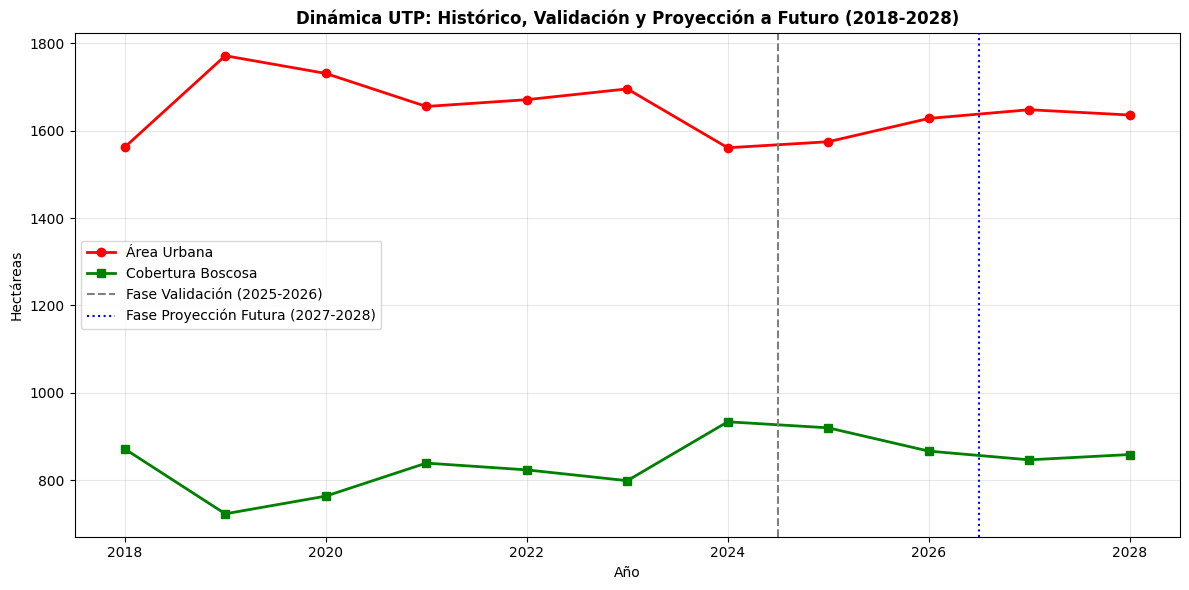

In [20]:
print("\nCalculando simulación de tendencia a futuro para 2027 y 2028...")

# Generar imágenes sintéticas para 2027 y 2028 basadas en el patrón histórico
ndvi_simulado_2027 = pendiente.multiply(2027).add(interseccion).rename('NDVI')
mapa_simulado_2027 = ndvi_simulado_2027.classify(clasificador_rf).clip(roi_estudio)
u_2027, b_2027 = obtener_hectareas(mapa_simulado_2027)

ndvi_simulado_2028 = pendiente.multiply(2028).add(interseccion).rename('NDVI')
mapa_simulado_2028 = ndvi_simulado_2028.classify(clasificador_rf).clip(roi_estudio)
u_2028, b_2028 = obtener_hectareas(mapa_simulado_2028)

# Combinar todas las listas
anios_totales = anios_estudio + [2027, 2028]
urbano_total = historico_urbano + [u_2027, u_2028]
bosque_total = historico_bosque + [b_2027, b_2028]

df_total = pd.DataFrame({'Año': anios_totales, 'Urbano': urbano_total, 'Bosque': bosque_total}).dropna()

# Dibujar la gráfica unificada
plt.figure(figsize=(12, 6))
plt.plot(df_total['Año'], df_total['Urbano'], color='red', marker='o', linewidth=2, label='Área Urbana')
plt.plot(df_total['Año'], df_total['Bosque'], color='green', marker='s', linewidth=2, label='Cobertura Boscosa')

# Líneas separadoras de fases
plt.axvline(x=2024.5, color='gray', linestyle='--', label='Fase Validación (2025-2026)')
plt.axvline(x=2026.5, color='blue', linestyle=':', label='Fase Proyección Futura (2027-2028)')

plt.title('Dinámica UTP: Histórico, Validación y Proyección a Futuro (2018-2028)', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Hectáreas')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
